 # SALES PERFORMANCE ANALYSIS PROJECT

IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Style

In [2]:
sns.set(style='whitegrid')

show all columns


In [3]:
pd.set_option('display.max_columns', None)

Replace with your dataset path


In [4]:
df = pd.read_csv("superstore_final_dataset.csv")

remove extra spaces from column names

In [5]:
df.columns = df.columns.str.strip()

 DATA OVERVIEW

In [6]:

print("===== FIRST 5 ROWS =====")
print(df.head())

print("\n===== DATASET SHAPE =====")
print(df.shape)

print("\n===== COLUMN NAMES =====")
print(df.columns)

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

===== FIRST 5 ROWS =====
   Row_ID        Order_ID  Order_Date   Ship_Date       Ship_Mode Customer_ID  \
0       1  CA-2017-152156  08-11-2017  11-11-2017    Second Class    CG-12520   
1       2  CA-2017-152156  08-11-2017  11-11-2017    Second Class    CG-12520   
2       3  CA-2017-138688  12-06-2017  16-06-2017    Second Class    DV-13045   
3       4  US-2016-108966  11-10-2016  18-10-2016  Standard Class    SO-20335   
4       5  US-2016-108966  11-10-2016  18-10-2016  Standard Class    SO-20335   

     Customer_Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   
4    Sean O Donnel   Consumer  United States  Fort Lauderdale     Florida   

   Postal_Code Region    

DATA CLEANING

In [7]:

# remove duplicates
df.drop_duplicates(inplace=True)

# convert date column
df['Order_Date'] = pd.to_datetime(
    df['Order_Date'],
    dayfirst=True
)

# create extra date columns
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month
df['Month_Name'] = df['Order_Date'].dt.month_name()

print("\n===== CLEANING COMPLETED =====")


===== CLEANING COMPLETED =====


KPI CALCULATIONS

In [8]:
total_revenue = df['Sales'].sum()

total_orders = df['Order_ID'].nunique()

average_sales = df['Sales'].mean()

top_region = df.groupby('Region')['Sales'].sum().idxmax()

top_category = df.groupby('Category')['Sales'].sum().idxmax()

print("\n========== KPI SUMMARY ==========")

print(f"Total Revenue: ${total_revenue:,.2f}")

print(f"Total Orders: {total_orders}")

print(f"Average Sales Value: ${average_sales:,.2f}")

print(f"Top Performing Region: {top_region}")

print(f"Top Performing Category: {top_category}")


========== KPI SUMMARY ==========
Total Revenue: $2,261,536.78
Total Orders: 4922
Average Sales Value: $230.77
Top Performing Region: West
Top Performing Category: Technology


MONTHLY SALES TREND

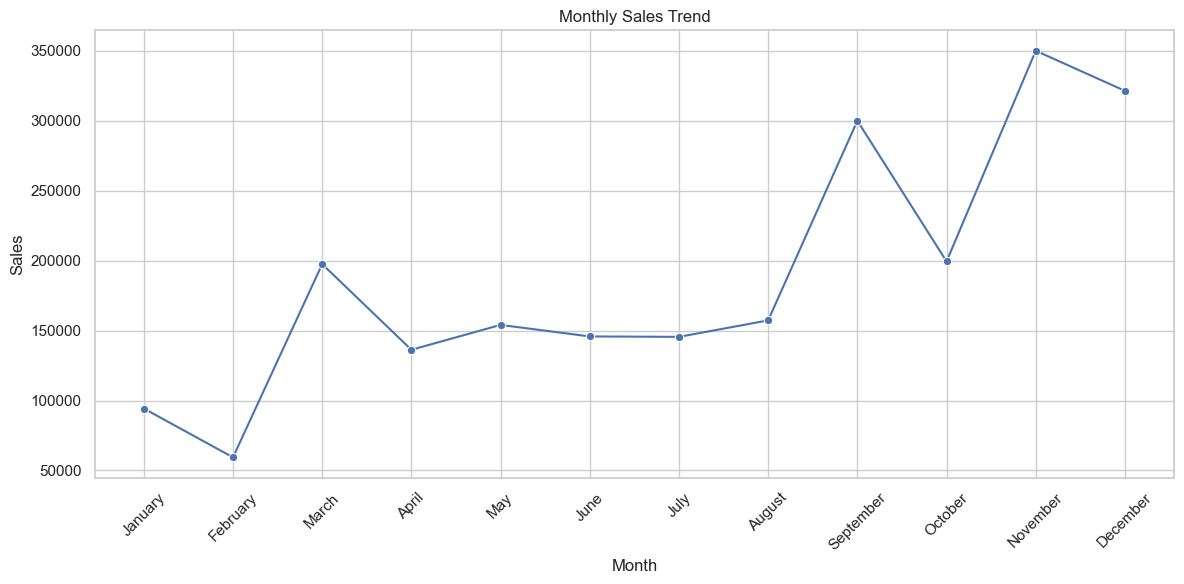

In [9]:
monthly_sales = df.groupby(
    'Month_Name'
)['Sales'].sum().reset_index()

# correct month order
months_order = [
    'January', 'February', 'March',
    'April', 'May', 'June',
    'July', 'August', 'September',
    'October', 'November', 'December'
]

monthly_sales['Month_Name'] = pd.Categorical(
    monthly_sales['Month_Name'],
    categories=months_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values('Month_Name')

plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_sales,
    x='Month_Name',
    y='Sales',
    marker='o'
)

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

REGIONAL ANALYSIS

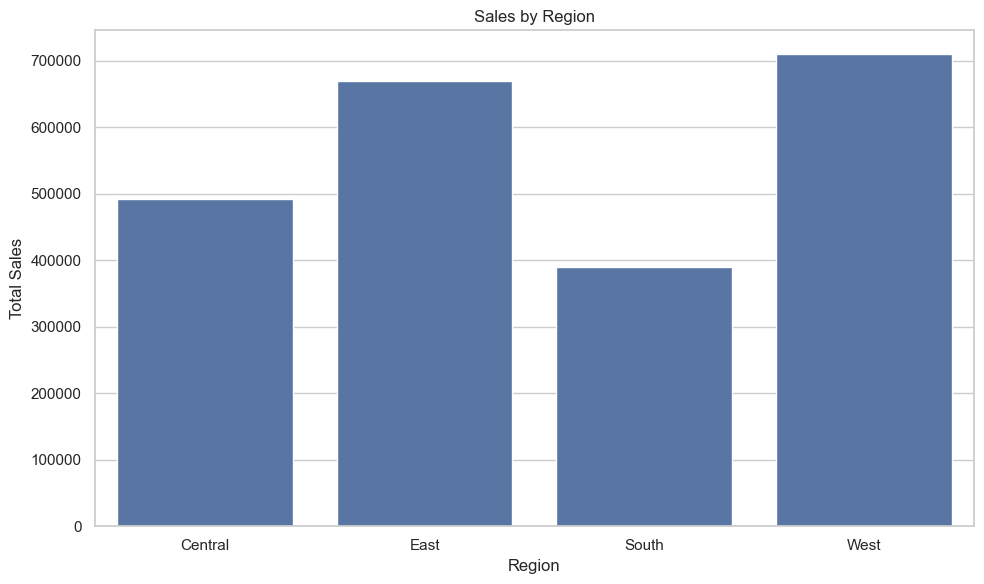

In [10]:
region_sales = df.groupby(
    'Region'
)['Sales'].sum().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=region_sales,
    x='Region',
    y='Sales'
)

plt.title("Sales by Region")

plt.xlabel("Region")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

CATEGORY ANALYSIS

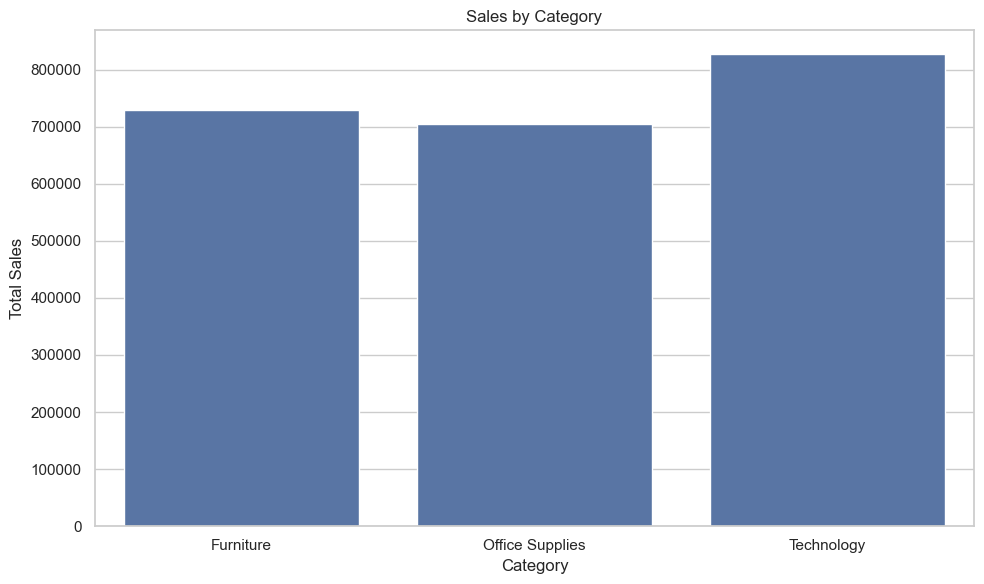

In [11]:

category_sales = df.groupby(
    'Category'
)['Sales'].sum().reset_index()

plt.figure(figsize=(10,6))

sns.barplot(
    data=category_sales,
    x='Category',
    y='Sales'
)

plt.title("Sales by Category")

plt.xlabel("Category")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()

 TOP 10 PRODUCTS

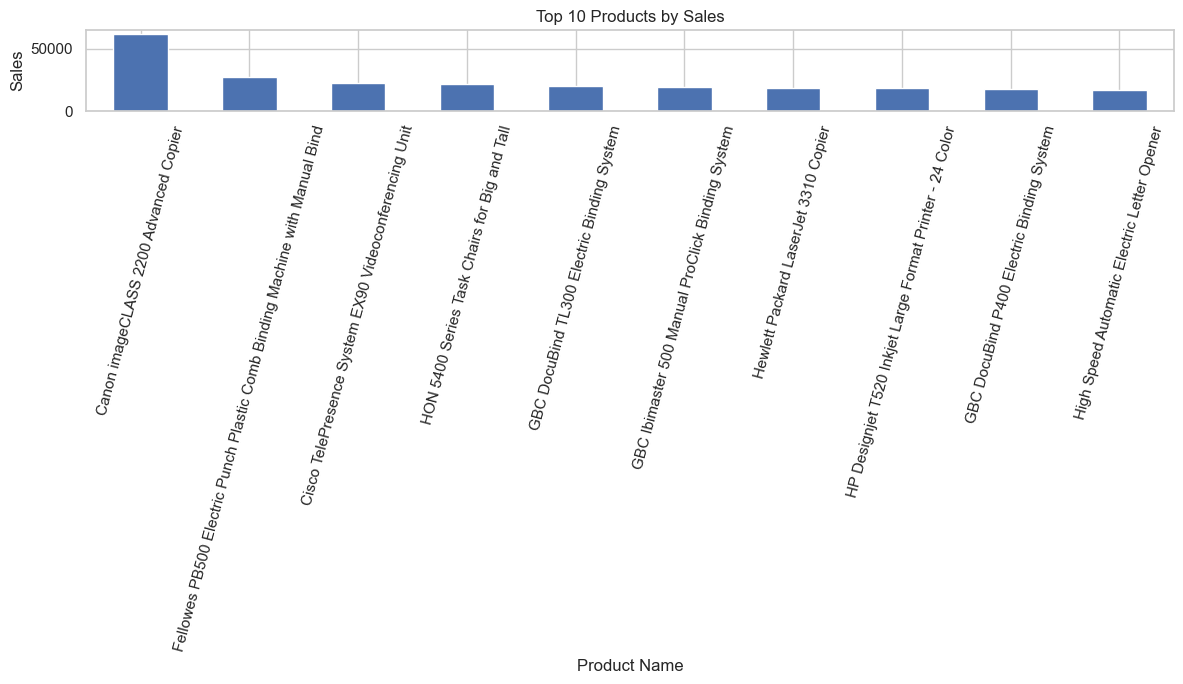

In [12]:
top_products = df.groupby(
    'Product_Name'
)['Sales'].sum().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(12,7))

top_products.plot(kind='bar')

plt.title("Top 10 Products by Sales")

plt.xlabel("Product Name")

plt.ylabel("Sales")

plt.xticks(rotation=75)

plt.tight_layout()

plt.show()

LOWEST SELLING PRODUCTS

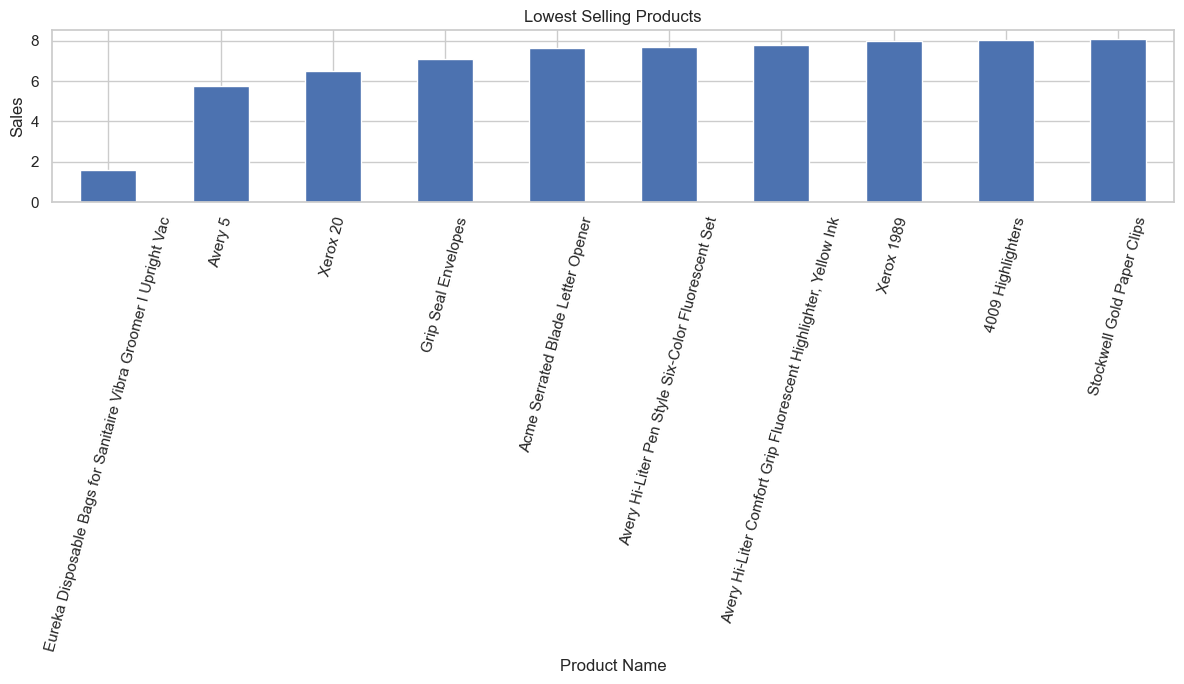

In [13]:
lowest_products = df.groupby(
    'Product_Name'
)['Sales'].sum().sort_values().head(10)

plt.figure(figsize=(12,7))

lowest_products.plot(kind='bar')

plt.title("Lowest Selling Products")

plt.xlabel("Product Name")

plt.ylabel("Sales")

plt.xticks(rotation=75)

plt.tight_layout()

plt.show()

HEATMAP (REGION VS CATEGORY)

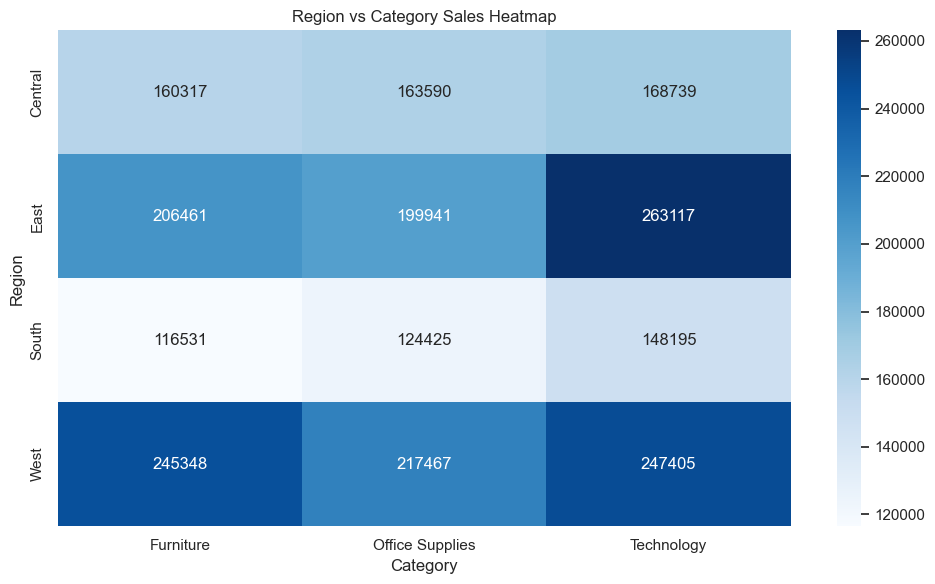

In [14]:

pivot_table = df.pivot_table(
    values='Sales',
    index='Region',
    columns='Category',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap='Blues'
)

plt.title("Region vs Category Sales Heatmap")

plt.tight_layout()

plt.show()

SEASONALITY ANALYSIS

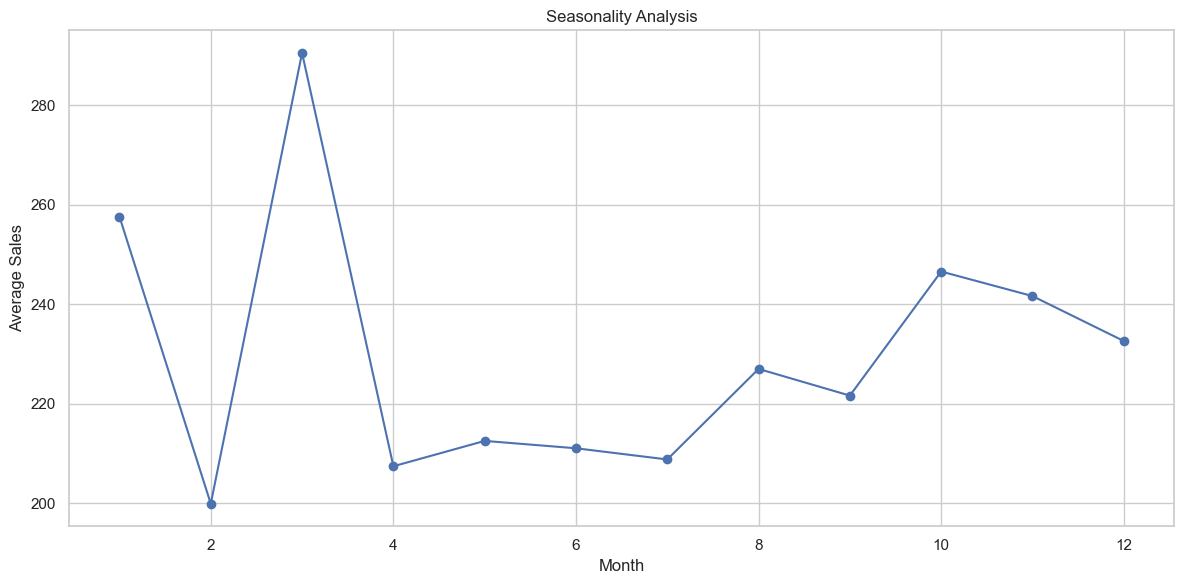

In [15]:
seasonality = df.groupby(
    'Month'
)['Sales'].mean()

plt.figure(figsize=(12,6))

seasonality.plot(marker='o')

plt.title("Seasonality Analysis")

plt.xlabel("Month")

plt.ylabel("Average Sales")

plt.grid(True)

plt.tight_layout()

plt.show()

CUSTOMER SEGMENT ANALYSIS

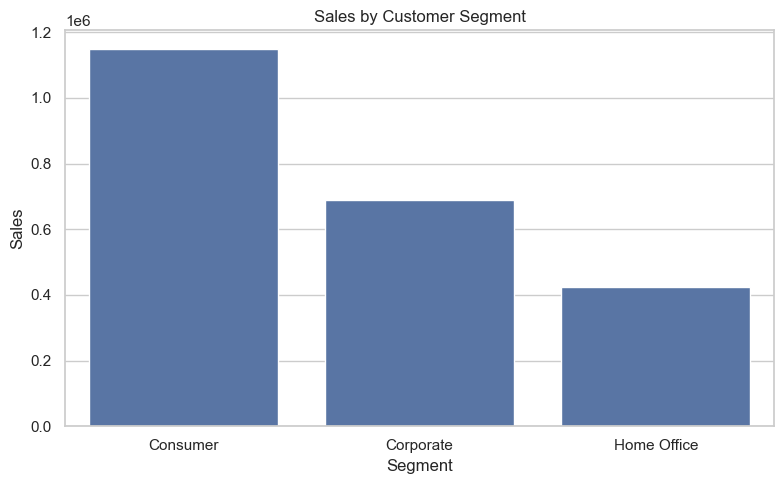

In [16]:
segment_sales = df.groupby(
    'Segment'
)['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_sales,
    x='Segment',
    y='Sales'
)

plt.title("Sales by Customer Segment")

plt.xlabel("Segment")

plt.ylabel("Sales")

plt.tight_layout()

plt.show()

 YEARLY SALES ANALYSIS

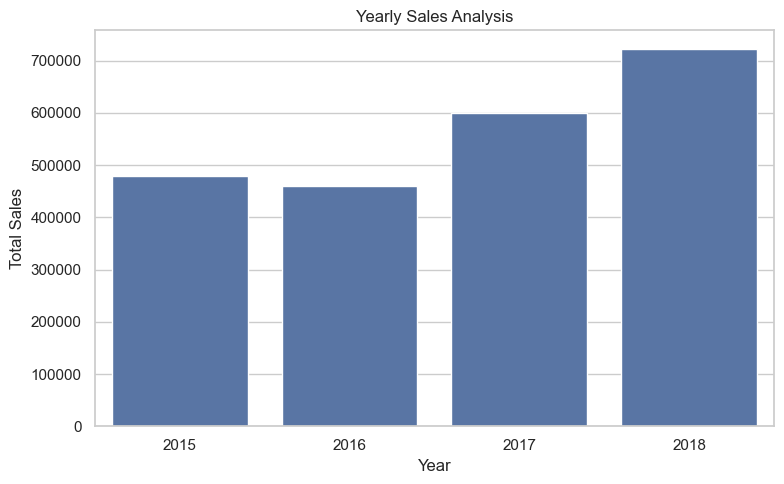

In [17]:

yearly_sales = df.groupby(
    'Year'
)['Sales'].sum().reset_index()

plt.figure(figsize=(8,5))

sns.barplot(
    data=yearly_sales,
    x='Year',
    y='Sales'
)

plt.title("Yearly Sales Analysis")

plt.xlabel("Year")

plt.ylabel("Total Sales")

plt.tight_layout()

plt.show()


EXPORT CLEAN DATA

In [18]:

df.to_csv(
    "cleaned_sales_data.csv",
    index=False
)

print("\nCleaned dataset exported successfully!")


Cleaned dataset exported successfully!


BUSINESS INSIGHTS

In [19]:
print("\n========== BUSINESS INSIGHTS ==========")

best_region = region_sales.sort_values(
    'Sales',
    ascending=False
).iloc[0]['Region']

best_category = category_sales.sort_values(
    'Sales',
    ascending=False
).iloc[0]['Category']

print(f"\nBest Performing Region: {best_region}")

print(f"Best Performing Category: {best_category}")

print("\nTop Recommendations:")

print("1. Increase marketing in high-performing regions.")

print("2. Promote top-selling products more aggressively.")

print("3. Improve sales in weak regions using targeted campaigns.")

print("4. Prepare inventory before peak seasonal months.")

print("5. Offer loyalty programs for high-value customer segments.")

print("\nPROJECT COMPLETED SUCCESSFULLY")


========== BUSINESS INSIGHTS ==========

Best Performing Region: West
Best Performing Category: Technology

Top Recommendations:
1. Increase marketing in high-performing regions.
2. Promote top-selling products more aggressively.
3. Improve sales in weak regions using targeted campaigns.
4. Prepare inventory before peak seasonal months.
5. Offer loyalty programs for high-value customer segments.

PROJECT COMPLETED SUCCESSFULLY
